> **License & Attribution**  
> This notebook is a derivative of [LLMs-from-scratch](https://github.com/rasbt/LLMs-from-scratch)  
> by Sebastian Raschka, licensed under the Apache License 2.0.  
> Modifications made by [enhennnn].  
>  
> SPDX-License-Identifier: Apache-2.0  
> For the full license text, see the [LICENSE](LICENSE) file in this repository

## 目录

1. 准备数据集
2. 创建Dataloader
3. 使用预训练权重初始化模型
4. 修改输出层为分类层
5. 分类的正确率和损失loss
6. 微调——监督训练
7. 使用模型作为垃圾邮件识别器
8. 模型保存和再次使用

&nbsp;
## 1. 准备数据集

- 在这里，我们进行分类微调，实现垃圾邮件识别

In [1]:
import urllib.request
import zipfile
import os
from pathlib import Path

# 确定SMS Spam Collection数据集网址
url = "https://archive.ics.uci.edu/static/public/228/sms+spam+collection.zip"
# 确定压缩包路径、解压文件夹路径和解压后文件路径
zip_path = "sms_spam_collection.zip"
extracted_path = "sms_spam_collection"
data_file_path = Path(extracted_path) / "SMSSpamCollection.tsv"

def download_and_unzip_spam_data(url, zip_path, extracted_path, data_file_path):
    if data_file_path.exists():
        print(f"{data_file_path} already exists. Skipping download and extraction.")
        return

    # 下载文件
    with urllib.request.urlopen(url) as response:
        with open(zip_path, "wb") as out_file:
            out_file.write(response.read())

    # 解压文件
    with zipfile.ZipFile(zip_path, "r") as zip_ref:
        zip_ref.extractall(extracted_path)
        
    # 添加.tsv文件扩展名
    original_file_path = Path(extracted_path) / "SMSSpamCollection"
    os.rename(original_file_path, data_file_path)
    print(f"File downloaded and saved as {data_file_path}")

download_and_unzip_spam_data(url, zip_path, extracted_path, data_file_path)

sms_spam_collection\SMSSpamCollection.tsv already exists. Skipping download and extraction.


In [2]:
import pandas as pd

# 检查载入的数据集
df = pd.read_csv(data_file_path, sep="\t", header=None, names=["Label", "Text"])
print(df["Label"].value_counts())
df

Label
ham     4825
spam     747
Name: count, dtype: int64


,Label,Text
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."
...,...,...
5567,spam,This is the 2nd time we have tried 2 contact u...
5568,ham,Will ü b going to esplanade fr home?
5569,ham,"Pity, * was in mood for that. So...any other s..."
5570,ham,The guy did some bitching but I acted like i'd...


In [3]:
# 构建更平衡的数据集，使得ham类样本数与spam类样本数相同
def create_balanced_dataset(df):
    # 计算spam类样本数
    num_spam = df[df["Label"] == "spam"].shape[0]
    # 对ham类随机采样，采样数与spam类样本数一致
    ham_subset = df[df["Label"] == "ham"].sample(num_spam, random_state=123)
    # 合并spam样本和ham样本
    balanced_df = pd.concat([ham_subset, df[df["Label"] == "spam"]])
    return balanced_df

balanced_df = create_balanced_dataset(df)
# 将ham和spam标签分别改为“0”和“1”
balanced_df["Label"] = balanced_df["Label"].map({"ham": 0, "spam": 1})  

# 检查修改后的更平衡的数据集
print(balanced_df["Label"].value_counts())
balanced_df  

Label
0    747
1    747
Name: count, dtype: int64


,Label,Text
4307,0,Awww dat is sweet! We can think of something t...
4138,0,Just got to &lt;#&gt;
4831,0,"The word ""Checkmate"" in chess comes from the P..."
4461,0,This is wishing you a great day. Moji told me ...
5440,0,Thank you. do you generally date the brothas?
...,...,...
5537,1,Want explicit SEX in 30 secs? Ring 02073162414...
5540,1,ASKED 3MOBILE IF 0870 CHATLINES INCLU IN FREE ...
5547,1,Had your contract mobile 11 Mnths? Latest Moto...
5566,1,REMINDER FROM O2: To get 2.50 pounds free call...


- 划分训练集、验证集、测试集

In [4]:
def random_split(df, train_frac, validation_frac):
    # 把原数据集打乱
    df = df.sample(frac=1, random_state=123).reset_index(drop=True)

    # 计算划分截止位置
    train_end = int(len(df) * train_frac)
    validation_end = train_end + int(len(df) * validation_frac)

    # 划分三种数据集
    train_df = df[:train_end]
    validation_df = df[train_end:validation_end]
    test_df = df[validation_end:]

    return train_df, validation_df, test_df

# 训练集比例为0.7，测试集比例为0.1
# 剩余部分为测试集，比例为 0.2
train_df, validation_df, test_df = random_split(balanced_df, 0.7, 0.1)

# 将划分好的数据集保存为csv格式
train_df.to_csv("train.csv", index=None)
validation_df.to_csv("validation.csv", index=None)
test_df.to_csv("test.csv", index=None)

&nbsp;
## 2. 创建Dataloader

- 在这里使用padding解决数据集长度不同的问题，使用token`<|endoftext|>` 作为填充标识符，其token ID为50256

In [5]:
import tiktoken

tokenizer = tiktoken.get_encoding("gpt2")
# 打印<|endoftext|>对应的token ID
print(tokenizer.encode("<|endoftext|>", allowed_special={"<|endoftext|>"}))

[50256]


In [6]:
import torch
from torch.utils.data import Dataset

# 写Dataset函数
class SpamDataset(Dataset):
    def __init__(self, csv_file, tokenizer, max_length=None, pad_token_id=50256):
        # 读入raw_data，处理Text列，划分token，再转为token ID
        self.data = pd.read_csv(csv_file)
        self.encoded_texts = [tokenizer.encode(text) for text in self.data["Text"]]

        if max_length is None:
            self.max_length = self._longest_encoded_length()
        else:
            # 如果指定了max_length，将Text截断
            self.max_length = max_length
            self.encoded_texts = [encoded_text[:self.max_length] for encoded_text in self.encoded_texts]

        # 填充token ID，至max_length长度
        self.encoded_texts = [
            encoded_text + [pad_token_id] * (self.max_length - len(encoded_text))
            for encoded_text in self.encoded_texts
        ]

    def __getitem__(self, index):
        encoded = self.encoded_texts[index]
        label = self.data.iloc[index]["Label"]
        return (
            torch.tensor(encoded, dtype=torch.long),
            torch.tensor(label, dtype=torch.long)
        )
    
    def __len__(self):
        return len(self.data)

    # 找出最长的token长度
    def _longest_encoded_length(self):
        max_length = 0
        for encoded_text in self.encoded_texts:
            encoded_length = len(encoded_text)
            if encoded_length > max_length:
                max_length = encoded_length
        return max_length

In [7]:
# 创建Dataset
train_dataset = SpamDataset(
    csv_file="train.csv",
    max_length=None,
    tokenizer=tokenizer
)
val_dataset = SpamDataset(
    csv_file="validation.csv",
    max_length=train_dataset.max_length,
    tokenizer=tokenizer
)
test_dataset = SpamDataset(
    csv_file="test.csv",
    max_length=train_dataset.max_length,
    tokenizer=tokenizer
)

In [8]:
from torch.utils.data import DataLoader

torch.manual_seed(123)
num_workers = 0
batch_size = 8

# 创建Dataloader
train_loader = DataLoader(
    dataset=train_dataset,
    batch_size=batch_size,
    shuffle=True,
    num_workers=num_workers,
    drop_last=True,
)
val_loader = DataLoader(
    dataset=val_dataset,
    batch_size=batch_size,
    num_workers=num_workers,
    drop_last=False,
)
test_loader = DataLoader(
    dataset=test_dataset,
    batch_size=batch_size,
    num_workers=num_workers,
    drop_last=False,
)

In [9]:
print(f"{len(train_loader)} training batches")
print(f"{len(val_loader)} validation batches")
print(f"{len(test_loader)} test batches")

130 training batches
19 validation batches
38 test batches


&nbsp;
## 3. 使用预训练权重初始化模型

In [10]:
CHOOSE_MODEL = "gpt2-small (124M)"
INPUT_PROMPT = "Every effort moves"

# 基础参数
BASE_CONFIG = {
    "vocab_size": 50257,     # 词表大小
    "context_length": 1024,  # 上下文长度
    "drop_rate": 0.0,        # Dropout率
    "qkv_bias": True         # 查询-键-值偏置
}
# 模型参数
model_configs = {
    "gpt2-small (124M)": {"emb_dim": 768, "n_layers": 12, "n_heads": 12},
    "gpt2-medium (355M)": {"emb_dim": 1024, "n_layers": 24, "n_heads": 16},
    "gpt2-large (774M)": {"emb_dim": 1280, "n_layers": 36, "n_heads": 20},
    "gpt2-xl (1558M)": {"emb_dim": 1600, "n_layers": 48, "n_heads": 25},
}

# 将模型参数的设置添加在基础参数中
BASE_CONFIG.update(model_configs[CHOOSE_MODEL])

# 断言语句，用于验证 train_dataset.max_length 是否符合模型的上下文长度（context_length）要求。
# 如果不符合，将抛出一个异常的讯号
assert train_dataset.max_length <= BASE_CONFIG["context_length"], (
    f"Dataset length {train_dataset.max_length} exceeds model's context "
    f"length {BASE_CONFIG['context_length']}. Reinitialize data sets with "
    f"`max_length={BASE_CONFIG['context_length']}`"
)

In [11]:
from gpt_download import download_and_load_gpt2
from pre_train_code import GPTModel, load_weights_into_gpt

# 从超参数CHOOSE_MODEL中确定下载模型大小
model_size = CHOOSE_MODEL.split(" ")[-1].lstrip("(").rstrip(")")
# 调用函数从OpenAI下载对应的gpt2模型
settings, params = download_and_load_gpt2(model_size=model_size, models_dir="gpt2")
# 实例化我们自己写的GPTModel模型
model = GPTModel(BASE_CONFIG)
# 将OpenAI的gpt2模型的参数导入我们自己写的GPTModel模型中
load_weights_into_gpt(model, params)

File already exists and is up-to-date: gpt2\124M\checkpoint
File already exists and is up-to-date: gpt2\124M\encoder.json
File already exists and is up-to-date: gpt2\124M\hparams.json
File already exists and is up-to-date: gpt2\124M\model.ckpt.data-00000-of-00001
File already exists and is up-to-date: gpt2\124M\model.ckpt.index
File already exists and is up-to-date: gpt2\124M\model.ckpt.meta
File already exists and is up-to-date: gpt2\124M\vocab.bpe


In [12]:
from pre_train_code import generate_text_simple, text_to_token_ids, token_ids_to_text

# 验证当前模型的自回归生成能力
text_1 = "Every effort moves you"
token_ids = generate_text_simple(
    model=model,
    idx=text_to_token_ids(text_1, tokenizer),
    max_new_tokens=15,
    context_size=BASE_CONFIG["context_length"]
)
print(token_ids_to_text(token_ids, tokenizer))

Every effort moves you forward.

The first step is to understand the importance of your work


In [13]:
# 验证当前模型是否有垃圾邮件识别能力
text_2 = (
    "Is the following text 'spam'? Answer with 'yes' or 'no':"
    " 'You are a winner you have been specially"
    " selected to receive $1000 cash or a $2000 award.'"
)
token_ids = generate_text_simple(
    model=model,
    idx=text_to_token_ids(text_2, tokenizer),
    max_new_tokens=25,
    context_size=BASE_CONFIG["context_length"]
)
# 发现目前不能实现垃圾邮件识别
print(token_ids_to_text(token_ids, tokenizer))

Is the following text 'spam'? Answer with 'yes' or 'no': 'You are a winner you have been specially selected to receive $1000 cash or a $2000 award.'

The following text 'spam'? Answer with 'yes' or 'no': 'You are a winner you have


&nbsp;
## 4. 修改输出层为分类层

- 原模型输出层是一个768维->50257维的线性层

- 现为实现垃圾邮件的识别分类，改为768维->2维的分类层

In [14]:
print(model)

GPTModel(
  (tok_emb): Embedding(50257, 768)
  (pos_emb): Embedding(1024, 768)
  (drop_emb): Dropout(p=0.0, inplace=False)
  (trf_blocks): Sequential(
    (0): TransformerBlock(
      (att): MultiHeadAttention(
        (W_query): Linear(in_features=768, out_features=768, bias=True)
        (W_key): Linear(in_features=768, out_features=768, bias=True)
        (W_value): Linear(in_features=768, out_features=768, bias=True)
        (out_proj): Linear(in_features=768, out_features=768, bias=True)
        (dropout): Dropout(p=0.0, inplace=False)
      )
      (ff): FeedForward(
        (layers): Sequential(
          (0): Linear(in_features=768, out_features=3072, bias=True)
          (1): GELU()
          (2): Linear(in_features=3072, out_features=768, bias=True)
        )
      )
      (norm1): LayerNorm()
      (norm2): LayerNorm()
      (drop_shortcut): Dropout(p=0.0, inplace=False)
    )
    (1): TransformerBlock(
      (att): MultiHeadAttention(
        (W_query): Linear(in_features=7

<img src="https://sebastianraschka.com/images/LLMs-from-scratch-images/ch06_compressed/10.webp" width=500px>

In [15]:
# 冻结原模型，使得所有层都变得不可训练
for param in model.parameters():
    param.requires_grad = False

In [16]:
torch.manual_seed(123)

# 修改输出层为分类层
num_classes = 2
model.out_head = torch.nn.Linear(in_features=BASE_CONFIG["emb_dim"], out_features=num_classes)

# 使最后一个transformer block和final norm参与训练
for param in model.trf_blocks[-1].parameters():
    param.requires_grad = True

for param in model.final_norm.parameters():
    param.requires_grad = True

&nbsp;
## 5. 分类的正确率和损失loss

In [17]:
# 输入
inputs = tokenizer.encode("Do you have time")
inputs = torch.tensor(inputs).unsqueeze(0)
print("Inputs:", inputs)
print("Inputs dimensions:", inputs.shape)

# 输出
with torch.no_grad():
    outputs = model(inputs)
print("Outputs:\n", outputs)
print("Outputs dimensions:", outputs.shape)

# 预测的后一个token的logits
last_token_logits = outputs[:, -1, :]
print("Last output token logits:", last_token_logits)

# 计算概率
probas = torch.softmax(last_token_logits, dim=-1)
label = torch.argmax(probas, dim=-1)
print("Last output token probas shape:", probas.shape)
print("Class label:", label.item())

Inputs: tensor([[5211,  345,  423,  640]])
Inputs dimensions: torch.Size([1, 4])
Outputs:
 tensor([[[-1.5854,  0.9904],
         [-3.7235,  7.4548],
         [-2.2661,  6.6049],
         [-3.5983,  3.9902]]])
Outputs dimensions: torch.Size([1, 4, 2])
Last output token logits: tensor([[-3.5983,  3.9902]])
Last output token probas shape: torch.Size([1, 2])
Class label: 1


In [18]:
# 计算正确率
def calc_accuracy_loader(data_loader, model, device, num_batches=None):
    model.eval()
    correct_predictions, num_predictions = 0, 0

    # 可以指定处理的batch数量
    if num_batches is None:
        num_batches = len(data_loader)
    else:
        num_batches = min(num_batches, len(data_loader))

    for i, (input_batch, target_batch) in enumerate(data_loader):
        if i < num_batches:
            input_batch, target_batch = input_batch.to(device), target_batch.to(device)
            with torch.no_grad():
                logits = model(input_batch)[:, -1, :]
            # 完整版：logits经过softmax得到probas，得到label
            #probas = torch.softmax(logits, dim=-1)
            #predicted_labels = torch.argmax(probas, dim=-1)
            # logits不经过softmax，直接得到label，节省开销
            predicted_labels = torch.argmax(logits, dim=-1)

            # 统计预测的样本总数和预测正确的数量
            num_predictions += predicted_labels.shape[0]
            correct_predictions += (predicted_labels == target_batch).sum().item()
        else:
            break

    return correct_predictions / num_predictions

In [19]:
torch.manual_seed(123)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device)

# 训练前，当前模型的预测正确率
train_accuracy = calc_accuracy_loader(train_loader, model, device, num_batches=10)
val_accuracy = calc_accuracy_loader(val_loader, model, device, num_batches=10)
test_accuracy = calc_accuracy_loader(test_loader, model, device, num_batches=10)
print(f"Training accuracy: {train_accuracy*100:.2f}%")
print(f"Validation accuracy: {val_accuracy*100:.2f}%")
print(f"Test accuracy: {test_accuracy*100:.2f}%")

Training accuracy: 46.25%
Validation accuracy: 45.00%
Test accuracy: 48.75%


- `calc_loss_batch`函数与ch4基本相同，只是我们只考虑最后一个token（即预测的token）的logits`model(input_batch)[:, -1, :]`，而无需考虑所有logits`model(input_batch)`

In [20]:
def calc_loss_batch(input_batch, target_batch, model, device):
    input_batch, target_batch = input_batch.to(device), target_batch.to(device)
    logits = model(input_batch)[:, -1, :]
    loss = torch.nn.functional.cross_entropy(logits, target_batch)
    return loss

def calc_loss_loader(data_loader, model, device, num_batches=None):
    total_loss = 0.
    if len(data_loader) == 0:
        return float("nan")
    elif num_batches is None:
        num_batches = len(data_loader)
    else:
        num_batches = min(num_batches, len(data_loader))
    for i, (input_batch, target_batch) in enumerate(data_loader):
        if i < num_batches:
            loss = calc_loss_batch(input_batch, target_batch, model, device)
            total_loss += loss.item()
        else:
            break
    return total_loss / num_batches
    

In [21]:
# 训练前，当前模型的loss
with torch.no_grad():
    train_loss = calc_loss_loader(train_loader, model, device, num_batches=5)
    val_loss = calc_loss_loader(val_loader, model, device, num_batches=5)
    test_loss = calc_loss_loader(test_loader, model, device, num_batches=5)
print(f"Training loss: {train_loss:.3f}")
print(f"Validation loss: {val_loss:.3f}")
print(f"Test loss: {test_loss:.3f}")

Training loss: 2.453
Validation loss: 2.583
Test loss: 2.322


&nbsp;
## 6. 微调——监督训练

In [22]:
# 和ch4预训练train_model_simple代码基本一样
def train_classifier_simple(model, train_loader, val_loader, optimizer, device, num_epochs,
                            eval_freq, eval_iter):

    train_losses, val_losses, train_accs, val_accs = [], [], [], []
    examples_seen, global_step = 0, -1

    for epoch in range(num_epochs):
        model.train() 

        for input_batch, target_batch in train_loader:
            optimizer.zero_grad() 
            loss = calc_loss_batch(input_batch, target_batch, model, device)
            loss.backward()
            optimizer.step() 

            examples_seen += input_batch.shape[0] 
            global_step += 1

            if global_step % eval_freq == 0:
                train_loss, val_loss = evaluate_model(model, train_loader, val_loader, device, eval_iter)
                
                train_losses.append(train_loss)
                val_losses.append(val_loss)
                print(f"Ep {epoch+1} (Step {global_step:06d}): "
                      f"Train loss {train_loss:.3f}, Val loss {val_loss:.3f}")


        train_accuracy = calc_accuracy_loader(train_loader, model, device, num_batches=eval_iter)
        val_accuracy = calc_accuracy_loader(val_loader, model, device, num_batches=eval_iter)
        print(f"Training accuracy: {train_accuracy*100:.2f}% | ", end="")
        print(f"Validation accuracy: {val_accuracy*100:.2f}%")
        train_accs.append(train_accuracy)
        val_accs.append(val_accuracy)

    return train_losses, val_losses, train_accs, val_accs, examples_seen


# 和ch4的evaluate_model相同
def evaluate_model(model, train_loader, val_loader, device, eval_iter):
    model.eval()
    with torch.no_grad():
        train_loss = calc_loss_loader(train_loader, model, device, num_batches=eval_iter)
        val_loss = calc_loss_loader(val_loader, model, device, num_batches=eval_iter)
    model.train()
    return train_loss, val_loss

In [23]:
import time

torch.manual_seed(123)

start_time = time.time()

num_epochs = 5
optimizer = torch.optim.AdamW(model.parameters(), lr=5e-5, weight_decay=0.1)
train_losses, val_losses, train_accs, val_accs, examples_seen = train_classifier_simple(
    model, train_loader, val_loader, optimizer, device,
    num_epochs=num_epochs, eval_freq=50, eval_iter=5,
)

end_time = time.time()
execution_time_minutes = (end_time - start_time) / 60
print(f"Training completed in {execution_time_minutes:.2f} minutes.")

Ep 1 (Step 000000): Train loss 2.153, Val loss 2.392
Ep 1 (Step 000050): Train loss 0.617, Val loss 0.637
Ep 1 (Step 000100): Train loss 0.523, Val loss 0.557
Training accuracy: 70.00% | Validation accuracy: 72.50%
Ep 2 (Step 000150): Train loss 0.561, Val loss 0.489
Ep 2 (Step 000200): Train loss 0.419, Val loss 0.397
Ep 2 (Step 000250): Train loss 0.409, Val loss 0.353
Training accuracy: 82.50% | Validation accuracy: 85.00%
Ep 3 (Step 000300): Train loss 0.333, Val loss 0.320
Ep 3 (Step 000350): Train loss 0.340, Val loss 0.306
Training accuracy: 90.00% | Validation accuracy: 90.00%
Ep 4 (Step 000400): Train loss 0.136, Val loss 0.200
Ep 4 (Step 000450): Train loss 0.153, Val loss 0.132
Ep 4 (Step 000500): Train loss 0.222, Val loss 0.137
Training accuracy: 100.00% | Validation accuracy: 97.50%
Ep 5 (Step 000550): Train loss 0.207, Val loss 0.143
Ep 5 (Step 000600): Train loss 0.083, Val loss 0.074
Training accuracy: 100.00% | Validation accuracy: 97.50%
Training completed in 0.51 mi

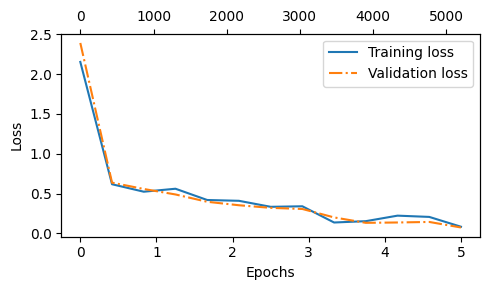

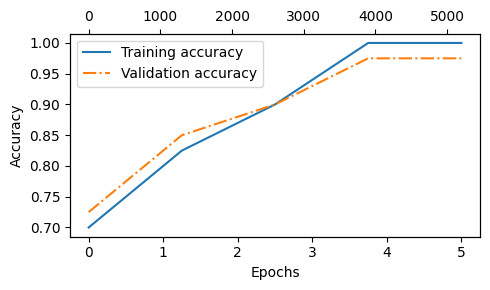

In [27]:
import matplotlib.pyplot as plt
# 绘图
def plot_values(epochs_seen, examples_seen, train_values, val_values, label="loss"):
    fig, ax1 = plt.subplots(figsize=(5, 3))

    ax1.plot(epochs_seen, train_values, label=f"Training {label}")
    ax1.plot(epochs_seen, val_values, linestyle="-.", label=f"Validation {label}")
    ax1.set_xlabel("Epochs")
    ax1.set_ylabel(label.capitalize())
    ax1.legend()

    ax2 = ax1.twiny()  
    ax2.plot(examples_seen, train_values, alpha=0)  

    fig.tight_layout()  
    plt.savefig(f"{label}-plot.pdf")
    plt.show()

# 绘制loss
epochs_tensor = torch.linspace(0, num_epochs, len(train_losses))
examples_seen_tensor = torch.linspace(0, examples_seen, len(train_losses))
plot_values(epochs_tensor, examples_seen_tensor, train_losses, val_losses)

# 绘制正确率
epochs_tensor = torch.linspace(0, num_epochs, len(train_accs))
examples_seen_tensor = torch.linspace(0, examples_seen, len(train_accs))
plot_values(epochs_tensor, examples_seen_tensor, train_accs, val_accs, label="accuracy")

In [28]:
# 训练后，当前模型的预测正确率
train_accuracy = calc_accuracy_loader(train_loader, model, device)
val_accuracy = calc_accuracy_loader(val_loader, model, device)
test_accuracy = calc_accuracy_loader(test_loader, model, device)
print(f"Training accuracy: {train_accuracy*100:.2f}%")
print(f"Validation accuracy: {val_accuracy*100:.2f}%")
print(f"Test accuracy: {test_accuracy*100:.2f}%")

Training accuracy: 97.21%
Validation accuracy: 97.32%
Test accuracy: 95.67%


&nbsp;
## 7. 使用模型作为垃圾邮件识别器

In [30]:
def classify_review(text, model, tokenizer, device, max_length=None, pad_token_id=50256):
    model.eval()
    input_ids = tokenizer.encode(text)

    # 获取模型支持的上下文长度，截断超过的部分
    supported_context_length = model.pos_emb.weight.shape[0]
    input_ids = input_ids[:min(max_length, supported_context_length)]
    # 如果剩下的部分不够，就padding填补token长度
    input_ids += [pad_token_id] * (max_length - len(input_ids))
    # 转换成张量tensor
    input_tensor = torch.tensor(input_ids, device=device).unsqueeze(0) 
  
    with torch.no_grad():
        logits = model(input_tensor)[:, -1, :] 
    predicted_label = torch.argmax(logits, dim=-1).item()
    
    return "spam" if predicted_label == 1 else "not spam"

In [31]:
text_1 = (
    "You are a winner you have been specially"
    " selected to receive $1000 cash or a $2000 award."
)
text_2 = (
    "Hey, just wanted to check if we're still on"
    " for dinner tonight? Let me know!"
)

print(classify_review(text_1, model, tokenizer, device, max_length=train_dataset.max_length))
print(classify_review(text_2, model, tokenizer, device, max_length=train_dataset.max_length))

spam
not spam


&nbsp;
## 8. 模型保存和再次使用

- 保存模型

In [32]:
torch.save(model.state_dict(), "review_classifier.pth")

- 下次使用时，加载模型

In [33]:
model_state_dict = torch.load("review_classifier.pth", map_location=device, weights_only=True)
model.load_state_dict(model_state_dict)

<All keys matched successfully>